# CELL 1 — Setup, Imports, and Config

In [ ]:
# =========================
# CELL 1 — Setup, Imports, and Config
# =========================

import os, json, time, warnings, re, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xgboost as xgb
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split, GroupKFold, GroupShuffleSplit, cross_val_score
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    confusion_matrix, classification_report
)
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score, balanced_accuracy_score,
    confusion_matrix, classification_report
)

import joblib
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

DATA_PATH = "/content/PhiUSIIL_Phishing_URL_Dataset.csv"


# CELL 2 — Load Dataset + Sanity Checks


In [ ]:
# =========================
# CELL 2 — Load Dataset + Sanity Checks
# =========================

df = pd.read_csv(DATA_PATH)

assert "label" in df.columns, "label column not found"
assert "URL" in df.columns, "URL column not found (needed for validation)"
assert "Domain" in df.columns, "Domain column not found (needed for domain-group split)"

print("Shape:", df.shape)
print("Columns:", len(df.columns))

# PhiUSIIL semantics: 0=phishing, 1=legitimate
vc = df["label"].value_counts().sort_index()
print("\nLabel distribution (0=phish, 1=legit):")
print(vc)
print("Legit rate:", (df["label"] == 1).mean().round(4), "| Phish rate:", (df["label"] == 0).mean().round(4))

print("\nDuplicate URL count:", df["URL"].duplicated().sum())
print("Duplicate Domain count:", df["Domain"].duplicated().sum())


Shape: (235795, 56)
Columns: 56

Label distribution (0=phish, 1=legit):
label
0    100945
1    134850
Name: count, dtype: int64
Legit rate: 0.5719 | Phish rate: 0.4281

Duplicate URL count: 425
Duplicate Domain count: 15709


# CELL 3 — Clean Columns + Select Features + Build X/y


In [ ]:
# =========================
# CELL 3 — Clean Columns + Select Features + Build X/y
# =========================

TEXT_ID_COLS = ["FILENAME", "URL", "Domain", "Title"]

LEAKAGE_COLS = [
    "URLSimilarityIndex", "TLDLegitimateProb", "URLCharProb",
    "DomainTitleMatchScore", "URLTitleMatchScore"
]

HEAVY_COLS = [
    "NoOfExternalRef", "LineOfCode", "NoOfSelfRef", "NoOfEmptyRef",
    "LargestLineLength", "NoOfImage", "NoOfCSS", "NoOfJS",
    "NoOfiFrame", "NoOfPopup", "NoOfSelfRedirect", "NoOfURLRedirect"
]

DROP_COLS = [c for c in (TEXT_ID_COLS + LEAKAGE_COLS + HEAVY_COLS) if c in df.columns]
df_clean = df.drop(columns=DROP_COLS, errors="ignore").copy()

print("Dropped:", len(DROP_COLS))
print("Remaining shape:", df_clean.shape)

FULL_FEATURES = [
    "URLLength", "NoOfSubDomain", "IsDomainIP", "TLDLength", "DomainLength",
    "NoOfLettersInURL", "NoOfDegitsInURL", "NoOfOtherSpecialCharsInURL",
    "NoOfQMarkInURL", "NoOfEqualsInURL", "NoOfAmpersandInURL",
    "NoOfObfuscatedChar", "HasObfuscation", "CharContinuationRate",
    "SpacialCharRatioInURL", "LetterRatioInURL", "DegitRatioInURL",
    "ObfuscationRatio", "IsHTTPS",
    "HasTitle", "HasFavicon", "Robots", "IsResponsive", "HasDescription",
    "HasExternalFormSubmit", "HasSocialNet", "HasSubmitButton",
    "HasHiddenFields", "HasPasswordField",
    "Bank", "Pay", "Crypto", "HasCopyrightInfo",
    "TLD"
]

URL_ONLY_FEATURES = [
    "URLLength", "NoOfSubDomain", "IsDomainIP", "TLDLength", "DomainLength",
    "NoOfLettersInURL", "NoOfDegitsInURL", "NoOfOtherSpecialCharsInURL",
    "NoOfQMarkInURL", "NoOfEqualsInURL", "NoOfAmpersandInURL",
    "NoOfObfuscatedChar", "HasObfuscation", "CharContinuationRate",
    "SpacialCharRatioInURL", "LetterRatioInURL", "DegitRatioInURL",
    "ObfuscationRatio", "IsHTTPS",
    "TLD"
]

full_feats = [c for c in FULL_FEATURES if c in df_clean.columns]
url_feats  = [c for c in URL_ONLY_FEATURES if c in df_clean.columns]

missing_full = sorted(set(FULL_FEATURES) - set(full_feats))
print("Full feats:", len(full_feats), "| URL-only feats:", len(url_feats))
if missing_full:
    print("Missing FULL features:", missing_full)

keep_cols = list(set(full_feats + ["label"]))
df_model = df_clean[keep_cols].copy()

print("df_model shape:", df_model.shape)

X = df_model.drop(columns=["label"])
y = df_model["label"].astype(int)


Dropped: 21
Remaining shape: (235795, 35)
Full feats: 34 | URL-only feats: 20
df_model shape: (235795, 35)


# CELL 4 — Split + TLD_freq Encoding (Train-Only) + Fill NA


In [ ]:
# =========================
# CELL 4 — Split + TLD_freq Encoding (Train-Only) + Stabilize + Fill NA
# =========================

from math import log1p

# Random stratified split baseline
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

# --- Train-only TLD frequency encoding (prevents leakage) ---
tld_freq = None
if "TLD" in X_train.columns:
    tld_freq = X_train["TLD"].value_counts(normalize=True)

    def _encode_tld(split_df: pd.DataFrame):
        # map, then mark unknowns explicitly
        raw = split_df["TLD"].map(tld_freq)  # NaN for unseen
        split_df["TLD_unknown"] = raw.isna().astype(int)

        # fill unknown freq = 0
        raw = raw.fillna(0.0)

        # stabilize: log1p(freq) and cap
        # (both help reduce over-dominance of .com etc.)
        raw = np.log1p(raw)
        raw = np.minimum(raw, 0.20)  # cap; tune if needed

        split_df["TLD_freq"] = raw.astype(float)
        split_df.drop(columns=["TLD"], inplace=True)

    for split in (X_train, X_val, X_test):
        _encode_tld(split)

# Fill NaN (should be none, but keep safe)
X_train = X_train.fillna(0)
X_val   = X_val.fillna(0)
X_test  = X_test.fillna(0)

feature_columns = list(X_train.columns)
print("Final feature count:", len(feature_columns))
print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)
print("Train legit rate:", y_train.mean().round(4), "| Test legit rate:", y_test.mean().round(4))


Final feature count: 35
Train/Val/Test: (188636, 35) (23579, 35) (23580, 35)
Train legit rate: 0.5719 | Test legit rate: 0.5719


# CELL 5 — Train Full XGBoost + Evaluate (Reviewer-Friendly Metrics)


In [ ]:
# =========================
# CELL 5 — Train Full XGBoost + Evaluate + Calibration (offline)
# =========================

from sklearn.linear_model import LogisticRegression

params = {
    "objective": "binary:logistic",
    "eval_metric": ["logloss", "error"],
    "eta": 0.1,
    "max_depth": 4,
    "min_child_weight": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "lambda": 2.0,
    "alpha": 0.5,
    "gamma": 0.1,
    "max_bin": 256,
    "tree_method": "hist",
    "seed": SEED,
    "nthread": -1
}

dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=feature_columns)
dval   = xgb.DMatrix(X_val,   label=y_val,   feature_names=feature_columns)
dtest  = xgb.DMatrix(X_test,  label=y_test,  feature_names=feature_columns)

bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=400,
    evals=[(dtrain, "train"), (dval, "val")],
    early_stopping_rounds=30,
    verbose_eval=50
)

print("Best iteration:", bst.best_iteration)

# -------------------------
# 1) Raw model outputs
# -------------------------
proba_legit = bst.predict(dtest)  # P(legit=1)
pred_legit  = (proba_legit >= 0.5).astype(int)

acc = accuracy_score(y_test, pred_legit)
auc = roc_auc_score(y_test, proba_legit)

cm = confusion_matrix(y_test, pred_legit)
tn, fp, fn, tp = cm.ravel()

# Paper-standard metrics
prec_legit = precision_score(y_test, pred_legit, pos_label=1)
rec_legit  = recall_score(y_test, pred_legit, pos_label=1)
f1_legit   = f1_score(y_test, pred_legit, pos_label=1)
bal_acc    = balanced_accuracy_score(y_test, pred_legit)
pr_auc     = average_precision_score(y_test, proba_legit, pos_label=1)

specificity = tn / (tn + fp) if (tn + fp) else 0.0
fpr = fp / (tn + fp) if (tn + fp) else 0.0
fnr = fn / (fn + tp) if (fn + tp) else 0.0

phish_to_legit = int(fp)
legit_to_phish = int(fn)

phish_miss_rate = phish_to_legit / (tn + fp) if (tn + fp) else 0.0
legit_false_alarm_rate = legit_to_phish / (fn + tp) if (fn + tp) else 0.0

print("\nPaper-standard metrics (pos_label = legitimate=1):")
print(f"Precision: {prec_legit:.6f}")
print(f"Recall:    {rec_legit:.6f}")
print(f"F1-score:  {f1_legit:.6f}")
print(f"Balanced Accuracy: {bal_acc:.6f}")
print(f"PR-AUC (Average Precision): {pr_auc:.6f}")
print(f"Specificity (TNR, phishing rejected): {specificity:.6f}")
print(f"FPR (phish->legit): {fpr:.6f}")
print(f"FNR (legit->phish): {fnr:.6f}")

print("\n=== FULL MODEL (Random Split) | 1=legitimate ===")
print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC:  {auc:.6f}")
print("Confusion matrix [[TN FP],[FN TP]]:", cm.tolist())

print("\nReviewer-friendly error rates:")
print(f"Legit flagged as phishing (false alarm): {legit_false_alarm_rate:.6f} ({legit_false_alarm_rate*100:.3f}%)")
print(f"Phishing missed as legit (miss rate):     {phish_miss_rate:.6f} ({phish_miss_rate*100:.3f}%)")

# -------------------------
# 2) Offline probability calibration (Platt scaling on margins)
# -------------------------
# Use XGBoost raw margins on VAL
m_val  = bst.predict(dval,  output_margin=True)
m_test = bst.predict(dtest, output_margin=True)

cal = LogisticRegression(solver="lbfgs")
cal.fit(m_val.reshape(-1, 1), y_val.values)

A = float(cal.coef_[0][0])
B = float(cal.intercept_[0])

def calibrated_prob_from_margin(margin: np.ndarray, A: float, B: float) -> np.ndarray:
    z = A * margin + B
    # stable sigmoid
    return 1.0 / (1.0 + np.exp(-np.clip(z, -50, 50)))

proba_legit_cal = calibrated_prob_from_margin(m_test, A, B)
pred_legit_cal  = (proba_legit_cal >= 0.5).astype(int)

acc_cal = accuracy_score(y_test, pred_legit_cal)
auc_cal = roc_auc_score(y_test, proba_legit_cal)

print("\n=== CALIBRATED FULL MODEL (Platt on margins) ===")
print(f"Cal A={A:.6f}  B={B:.6f}")
print(f"Accuracy: {acc_cal:.6f} | ROC-AUC: {auc_cal:.6f}")

# Keep calibration params for later export/metadata
full_calibrator = {"A": A, "B": B, "space": "margin", "maps_to": "P(legit)"}


[0]	train-logloss:0.59491	train-error:0.42810	val-logloss:0.59494	val-error:0.42809
[50]	train-logloss:0.01467	train-error:0.00268	val-logloss:0.01403	val-error:0.00229
[100]	train-logloss:0.00476	train-error:0.00131	val-logloss:0.00413	val-error:0.00110
[150]	train-logloss:0.00308	train-error:0.00076	val-logloss:0.00265	val-error:0.00085
[200]	train-logloss:0.00244	train-error:0.00063	val-logloss:0.00210	val-error:0.00076
[250]	train-logloss:0.00212	train-error:0.00052	val-logloss:0.00189	val-error:0.00059
[300]	train-logloss:0.00191	train-error:0.00047	val-logloss:0.00178	val-error:0.00055
[304]	train-logloss:0.00189	train-error:0.00046	val-logloss:0.00176	val-error:0.00059
Best iteration: 274

Paper-standard metrics (pos_label = legitimate=1):
Precision: 0.999111
Recall:    0.999555
F1-score:  0.999333
Balanced Accuracy: 0.999183
PR-AUC (Average Precision): 0.999994
Specificity (TNR, phishing rejected): 0.998811
FPR (phish->legit): 0.001189
FNR (legit->phish): 0.000445

=== FULL MOD

# CELL 6 — Baselines + Domain Generalization Checks (CV, Overlap, GroupKFold, GroupShuffleSplit)


In [ ]:
# =========================
# CELL 6 — Baselines + Domain Generalization Checks (CV, Overlap, GroupKFold, GroupShuffleSplit)
# =========================

# Baseline sklearn-style CV on TRAIN ONLY (random split)
xgb_clf = XGBClassifier(
    objective="binary:logistic",
    learning_rate=params["eta"],
    max_depth=params["max_depth"],
    min_child_weight=params["min_child_weight"],
    subsample=params["subsample"],
    colsample_bytree=params["colsample_bytree"],
    reg_lambda=params["lambda"],
    reg_alpha=params["alpha"],
    gamma=params["gamma"],
    random_state=SEED,
    n_estimators=200,
    n_jobs=-1
)

cv_scores = cross_val_score(xgb_clf, X_train, y_train, cv=5, scoring="accuracy", n_jobs=-1)
print(f"5-fold CV accuracy (train only): {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

# Domain overlap check for the RANDOM split
train_domains = df.loc[X_train.index, "Domain"].astype(str).values
test_domains  = df.loc[X_test.index,  "Domain"].astype(str).values
overlap = len(set(train_domains) & set(test_domains))

print("\nDomain overlap diagnostic (random split):")
print("Unique train domains:", len(np.unique(train_domains)))
print("Unique test domains: ", len(np.unique(test_domains)))
print("Overlap domains:     ", overlap)

# GroupKFold generalization estimate (across train+test from random split baseline)
X_all = pd.concat([X_train, X_test], axis=0)
y_all = pd.concat([y_train, y_test], axis=0)
domains_all = df.loc[X_all.index, "Domain"].astype(str).values

gkf = GroupKFold(n_splits=5)
fold_acc = []

print("\nGroupKFold (domain-disjoint folds):")
for k, (tr, va) in enumerate(gkf.split(X_all, y_all, groups=domains_all), 1):
    model = XGBClassifier(**xgb_clf.get_params())
    model.fit(X_all.iloc[tr], y_all.iloc[tr])
    pred = model.predict(X_all.iloc[va])
    a = accuracy_score(y_all.iloc[va], pred)
    fold_acc.append(a)
    print(f"Fold {k}: {a:.4f} | train domains={len(np.unique(domains_all[tr]))} | val domains={len(np.unique(domains_all[va]))}")

print(f"GroupKFold mean acc: {np.mean(fold_acc):.4f} (±{np.std(fold_acc):.4f})")

# One-shot domain-disjoint holdout (unseen domains)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
tr_idx, te_idx = next(gss.split(X_all, y_all, groups=domains_all))

X_tr_g, y_tr_g = X_all.iloc[tr_idx], y_all.iloc[tr_idx]
X_te_g, y_te_g = X_all.iloc[te_idx], y_all.iloc[te_idx]

dom_tr, dom_te = domains_all[tr_idx], domains_all[te_idx]

print("\nGroupShuffleSplit (unseen domains holdout):")
print("Train domains:", len(np.unique(dom_tr)))
print("Test domains: ", len(np.unique(dom_te)))
print("Overlap:", len(set(dom_tr) & set(dom_te)))

model_g = XGBClassifier(**xgb_clf.get_params())
model_g.fit(X_tr_g, y_tr_g)
pred_g = model_g.predict(X_te_g)
acc_g = accuracy_score(y_te_g, pred_g)
print(f"Accuracy on unseen domains: {acc_g:.4f}")


5-fold CV accuracy (train only): 0.9991 (±0.0002)

Domain overlap diagnostic (random split):
Unique train domains: 176942
Unique test domains:  22797
Overlap domains:      1178

GroupKFold (domain-disjoint folds):
Fold 1: 0.9994 | train domains=158853 | val domains=39708
Fold 2: 0.9989 | train domains=158849 | val domains=39712
Fold 3: 0.9992 | train domains=158848 | val domains=39713
Fold 4: 0.9991 | train domains=158847 | val domains=39714
Fold 5: 0.9991 | train domains=158847 | val domains=39714
GroupKFold mean acc: 0.9992 (±0.0002)

GroupShuffleSplit (unseen domains holdout):
Train domains: 158848
Test domains:  39713
Overlap: 0
Accuracy on unseen domains: 0.9991


# CELL 7 — URL-only Model + Latency Benchmark + Save Artifacts + Metadata


In [ ]:
# =========================
# CELL 7 — URL-only Model + Latency + Save Artifacts + Metadata (with calibration export)
# =========================

from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score, balanced_accuracy_score,
    confusion_matrix, classification_report
)

# ---- URL-only columns (must match extension extractor) ----
URL_ONLY_SET = set([
    "URLLength","NoOfSubDomain","IsDomainIP","TLDLength","DomainLength",
    "NoOfLettersInURL","NoOfDegitsInURL","NoOfOtherSpecialCharsInURL",
    "NoOfQMarkInURL","NoOfEqualsInURL","NoOfAmpersandInURL",
    "NoOfObfuscatedChar","HasObfuscation","CharContinuationRate",
    "SpacialCharRatioInURL","LetterRatioInURL","DegitRatioInURL",
    "ObfuscationRatio","IsHTTPS","TLD_freq",
    "TLD_unknown",   # IMPORTANT (your extractor produces it)
])

url_only_cols = [c for c in feature_columns if c in URL_ONLY_SET]
print("URL-only feature count:", len(url_only_cols))
assert len(url_only_cols) > 0, "No URL-only features found. Check URL_ONLY_SET vs feature_columns."

dtrain_u = xgb.DMatrix(X_train[url_only_cols], label=y_train, feature_names=url_only_cols)
dtest_u  = xgb.DMatrix(X_test[url_only_cols],  label=y_test,  feature_names=url_only_cols)

# ---- Train URL-only model ----
params_url = params.copy()
params_url["max_depth"] = 6
params_url["eta"] = 0.15

url_model = xgb.train(params_url, dtrain_u, num_boost_round=200, verbose_eval=False)

# ---- Predictions: P(legit=1) ----
proba_legit_u = url_model.predict(dtest_u)
pred_legit_u  = (proba_legit_u >= 0.5).astype(int)

# ---- Metrics ----
acc_u = accuracy_score(y_test, pred_legit_u)
auc_u = roc_auc_score(y_test, proba_legit_u)
pr_auc_u = average_precision_score(y_test, proba_legit_u, pos_label=1)

prec_u = precision_score(y_test, pred_legit_u, pos_label=1)
rec_u  = recall_score(y_test, pred_legit_u, pos_label=1)
f1_u   = f1_score(y_test, pred_legit_u, pos_label=1)
bal_acc_u = balanced_accuracy_score(y_test, pred_legit_u)

cm_u = confusion_matrix(y_test, pred_legit_u)
tn_u, fp_u, fn_u, tp_u = cm_u.ravel()

phish_miss_rate_u = fp_u / (tn_u + fp_u) if (tn_u + fp_u) else 0.0  # phish -> legit
legit_false_alarm_rate_u = fn_u / (fn_u + tp_u) if (fn_u + tp_u) else 0.0  # legit -> phish
specificity_u = tn_u / (tn_u + fp_u) if (tn_u + fp_u) else 0.0

print("\n=== URL-ONLY MODEL (Random Split) | label=1 means legitimate ===")
print(f"Accuracy:  {acc_u:.6f}")
print(f"ROC-AUC:   {auc_u:.6f}")
print(f"PR-AUC(AP):{pr_auc_u:.6f}")
print("Confusion matrix [[TN FP],[FN TP]]:", cm_u.tolist())

print("\nPaper metrics (pos_label=legitimate=1):")
print(f"Precision: {prec_u:.6f}")
print(f"Recall:    {rec_u:.6f}")
print(f"F1-score:  {f1_u:.6f}")
print(f"Balanced Accuracy: {bal_acc_u:.6f}")

print("\nSecurity-oriented error rates:")
print(f"Legit false alarm (legit->phish): {legit_false_alarm_rate_u:.6f} ({legit_false_alarm_rate_u*100:.3f}%)")
print(f"Phish miss (phish->legit):        {phish_miss_rate_u:.6f} ({phish_miss_rate_u*100:.3f}%)")
print(f"Specificity (phish rejected):     {specificity_u:.6f}")

print("\nClassification report (0=phish, 1=legit):")
print(classification_report(y_test, pred_legit_u, digits=6))

# ---- Latency benchmark ----
def benchmark_latency(model: xgb.Booster, X_df: pd.DataFrame, feature_names, n=200):
    Xn = X_df.iloc[:n].copy()

    t0 = time.perf_counter()
    for i in range(n):
        dm = xgb.DMatrix(Xn.iloc[i:i+1], feature_names=feature_names)
        _ = model.predict(dm)
    t1 = time.perf_counter()
    ms1 = (t1 - t0) / n * 1000

    b = min(100, n)
    dmB = xgb.DMatrix(Xn.iloc[:b], feature_names=feature_names)
    t0 = time.perf_counter()
    _ = model.predict(dmB)
    t1 = time.perf_counter()
    msB = (t1 - t0) / b * 1000

    return ms1, msB

ms1_full, msB_full = benchmark_latency(bst, X_test[feature_columns], feature_columns, n=200)
ms1_url,  msB_url  = benchmark_latency(url_model, X_test[url_only_cols], url_only_cols, n=200)

print("\nLatency (ms/sample):")
print(f"Full model  batch-1: {ms1_full:.3f} | batch-100 equiv: {msB_full:.3f}")
print(f"URL-only    batch-1: {ms1_url:.3f} | batch-100 equiv: {msB_url:.3f}")

# ---- Save models + artifacts ----
bst.save_model("phishguard_full_xgb.json")
url_model.save_model("phishguard_url_only_xgb.json")

joblib.dump(feature_columns, "feature_columns_full.pkl")
joblib.dump(url_only_cols, "feature_columns_url_only.pkl")
joblib.dump(params, "train_params_full.pkl")

# ---- Metadata ----
metadata = {
    "project": "PhishGuard-Light",
    "seed": SEED,
    "label_semantics": {"0": "phishing", "1": "legitimate"},
    "dataset_rows": int(len(df)),
    "features_full": feature_columns,
    "features_url_only": url_only_cols,
    "random_split_full": {
        "threshold_legit": 0.50,
        "accuracy": float(acc),
        "roc_auc": float(auc),
        "cm": cm.tolist(),
        "phish_miss_rate": float(phish_miss_rate),
        "legit_false_alarm_rate": float(legit_false_alarm_rate),
    },
    "random_split_url_only": {
        "threshold_legit": 0.50,
        "accuracy": float(acc_u),
        "roc_auc": float(auc_u),
        "pr_auc": float(pr_auc_u),
        "precision_legit": float(prec_u),
        "recall_legit": float(rec_u),
        "f1_legit": float(f1_u),
        "balanced_accuracy": float(bal_acc_u),
        "cm": cm_u.tolist(),
        "phish_miss_rate": float(phish_miss_rate_u),
        "legit_false_alarm_rate": float(legit_false_alarm_rate_u),
        "specificity_phish_rejected": float(specificity_u),
    },
    "domain_generalization": {
        "groupkfold_mean_acc": float(np.mean(fold_acc)) if "fold_acc" in locals() else None,
        "groupshufflesplit_acc": float(acc_g) if "acc_g" in locals() else None
    },
    "latency_ms": {
        "full_batch1": float(ms1_full),
        "url_only_batch1": float(ms1_url),
    }
}

with open("model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("\nSaved files:")
print(" - phishguard_full_xgb.json")
print(" - phishguard_url_only_xgb.json")
print(" - feature_columns_full.pkl")
print(" - feature_columns_url_only.pkl")
print(" - train_params_full.pkl")
print(" - model_metadata.json")


URL-only feature count: 21

=== URL-ONLY MODEL (Random Split) | label=1 means legitimate ===
Accuracy:  0.996607
ROC-AUC:   0.998709
PR-AUC(AP):0.998572
Confusion matrix [[TN FP],[FN TP]]: [[10022, 73], [7, 13478]]

Paper metrics (pos_label=legitimate=1):
Precision: 0.994613
Recall:    0.999481
F1-score:  0.997041
Balanced Accuracy: 0.996125

Security-oriented error rates:
Legit false alarm (legit->phish): 0.000519 (0.052%)
Phish miss (phish->legit):        0.007231 (0.723%)
Specificity (phish rejected):     0.992769

Classification report (0=phish, 1=legit):
              precision    recall  f1-score   support

           0   0.999302  0.992769  0.996025     10095
           1   0.994613  0.999481  0.997041     13485

    accuracy                       0.996607     23580
   macro avg   0.996957  0.996125  0.996533     23580
weighted avg   0.996620  0.996607  0.996606     23580


Latency (ms/sample):
Full model  batch-1: 7.085 | batch-100 equiv: 0.011
URL-only    batch-1: 4.109 | batc

# CELL 8 — SHAP (Install Once) + Global Plots + Local Template Explanation


SHAP computed. Shape: (23580, 35)


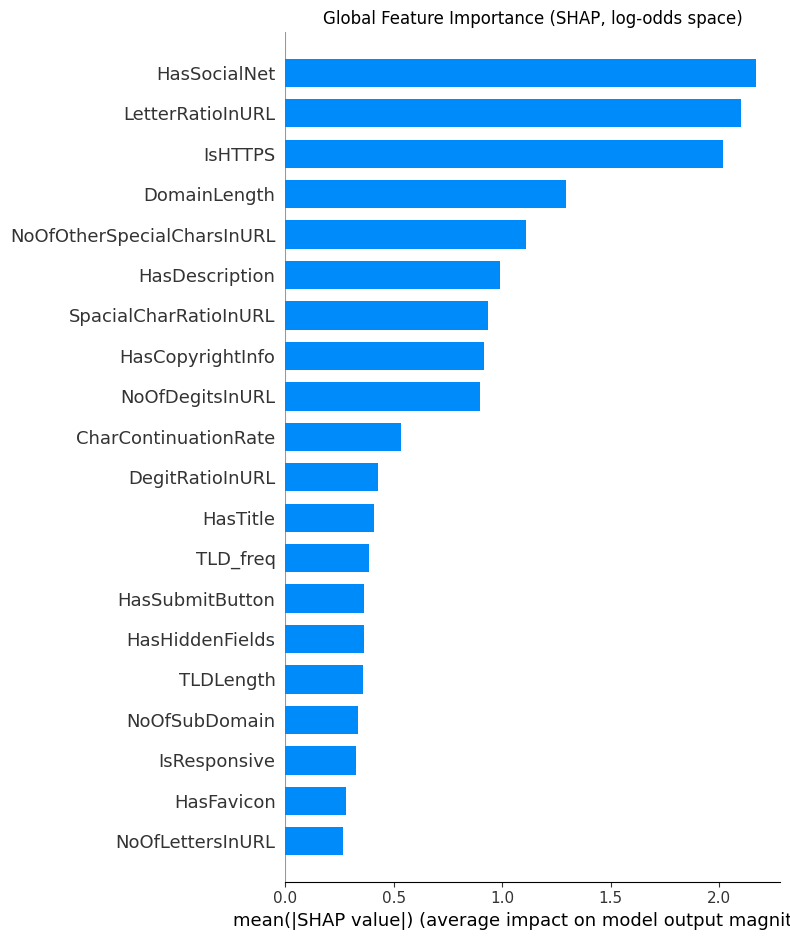

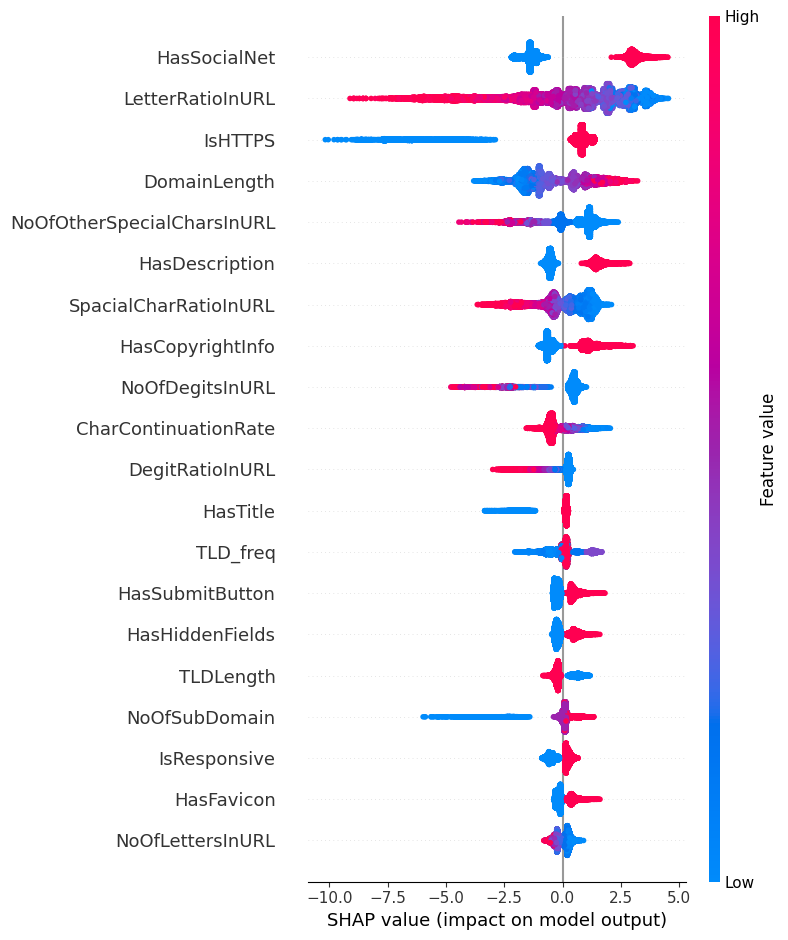


Example local explanation
P(legit) = 3.0364549274963792e-06 | True label = 0 (1=legit,0=phish)
 - ✅ Uses HTTPS (often increases legitimacy confidence) (value=0.000, shap=-6.4361, increased phishing risk in log-odds)
 - Feature 'HasTitle' influenced the decision (value=0.000, shap=-1.9870, increased phishing risk in log-odds)
 - Feature 'HasSocialNet' influenced the decision (value=0.000, shap=-1.3946, increased phishing risk in log-odds)


In [ ]:
# =========================
# CELL 8 — SHAP (Install Once) + Global Plots + Local Template Explanation
# =========================

!pip -q install shap

import shap

# NOTE: model_output="raw" => explanations are in log-odds (margin), NOT probability.
# If you want probability SHAP, try model_output="probability" (may be slower / version-dependent).

X_shap = X_test[feature_columns].copy()

explainer = shap.TreeExplainer(
    bst,
    feature_perturbation="tree_path_dependent",
    model_output="raw"
)

shap_values = explainer.shap_values(X_shap)

print("SHAP computed. Shape:", np.array(shap_values).shape)

# Global importance (bar)
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_columns,
    plot_type="bar",
    show=False
)
plt.title("Global Feature Importance (SHAP, log-odds space)")
plt.tight_layout()
plt.show()

# Global distribution plot
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_columns,
    show=False
)
plt.tight_layout()
plt.show()

EXPLANATION_TEMPLATES = {
    "IsDomainIP": "⚠️ URL uses a numeric IP address (common in phishing)",
    "NoOfSubDomain": "⚠️ Multiple subdomains may hide the true destination",
    "URLLength": "⚠️ Unusually long URL detected",
    "NoOfDegitsInURL": "⚠️ High digit count in URL (suspicious)",
    "CharContinuationRate": "⚠️ Unusual character repetition pattern detected",
    "HasPasswordField": "⚠️ Password field present (suspicious if unexpected)",
    "HasExternalFormSubmit": "⚠️ Form submits to an external destination",
    "IsHTTPS": "✅ Uses HTTPS (often increases legitimacy confidence)",
}

def generate_explanation(shap_row, feature_row, feature_names, top_k=3):
    contribs = list(zip(feature_names, shap_row))
    top_feats = sorted(contribs, key=lambda x: abs(x[1]), reverse=True)[:top_k]

    explanations = []
    for feat, shap_val in top_feats:
        val = float(feature_row[feat])
        direction = "increased legitimacy confidence" if shap_val > 0 else "increased phishing risk"
        template = EXPLANATION_TEMPLATES.get(feat, f"Feature '{feat}' influenced the decision")
        explanations.append(f"{template} (value={val:.3f}, shap={shap_val:.4f}, {direction} in log-odds)")
    return explanations

# Example explanation for one test sample
i = 0
print("\nExample local explanation")
print("P(legit) =", float(proba_legit[i]), "| True label =", int(y_test.iloc[i]), "(1=legit,0=phish)")
for line in generate_explanation(shap_values[i], X_shap.iloc[i], feature_columns, top_k=3):
    print(" -", line)


# CELL 9 — URL Extractor Demo + Threshold Sweep + Policy Thresholds + Extension Export (ZIP) + Reload Check


In [ ]:
# =========================
# Cell 9 — URL feature extractor (FINAL, self-contained, parity-oriented)
# Uses dataset-style URL string: (host + path + ?query), scheme removed.
# CharContinuationRate is computed on the L/D/S pattern of that string.
# =========================

import re
import numpy as np
from urllib.parse import urlparse


# -------------------------------------------------
# Safe TLD frequency map fallback
# (If you didn't build TLD_FREQ_MAP earlier, we use a small default.)
# Best practice: build this from training data TLD distribution.
# -------------------------------------------------
try:
    TLD_FREQ_MAP
except NameError:
    TLD_FREQ_MAP = {
        "com": 0.47664814775546555,
        "org": 0.045,
        "net": 0.037,
        "edu": 0.009,
        "gov": 0.006,
    }


# -------------------------------------------------
# Helper: continuation rate
# Fraction of adjacent characters that are identical:
# (# of i where s[i] == s[i-1]) / (len(s)-1)
# -------------------------------------------------
def char_continuation_rate(s: str) -> float:
    if s is None or len(s) < 2:
        return 0.0
    same = 0
    for i in range(1, len(s)):
        if s[i] == s[i - 1]:
            same += 1
    return same / (len(s) - 1)


# -------------------------------------------------
# Main extractor
# -------------------------------------------------
def extract_url_features_for_model(url: str) -> dict:
    feats = {}

    parsed = urlparse(url)
    host = (parsed.hostname or "").lower()
    path = parsed.path or ""
    query = parsed.query or ""

    # Dataset-style URL string (scheme removed)
    # IMPORTANT: include host + path + query (if present)
    u_ds = (host + path + ("?" + query if query else "")).lower()
    L_ds = max(len(u_ds), 1)

    # -------------------------
    # Lengths & counts
    # -------------------------
    feats["URLLength"] = float(len(u_ds))

    feats["NoOfLettersInURL"] = float(sum(c.isalpha() for c in u_ds))
    feats["NoOfDegitsInURL"] = float(sum(c.isdigit() for c in u_ds))

    # "Other special chars" = all non-alphanumeric characters
    feats["NoOfOtherSpecialCharsInURL"] = float(sum(not c.isalnum() for c in u_ds))

    feats["NoOfAmpersandInURL"] = float(u_ds.count("&"))
    feats["NoOfEqualsInURL"] = float(u_ds.count("="))
    feats["NoOfQMarkInURL"] = float(u_ds.count("?"))

    # -------------------------
    # Domain features
    # -------------------------
    feats["DomainLength"] = float(len(host))
    feats["NoOfSubDomain"] = float(max(host.count(".") - 1, 0))

    feats["IsDomainIP"] = float(bool(re.fullmatch(r"\d{1,3}(\.\d{1,3}){3}", host)))
    feats["IsHTTPS"] = float(parsed.scheme.lower() == "https")

    # -------------------------
    # Obfuscation
    # -------------------------
    # NOTE: Keep these tokens simple and consistent with training.
    feats["HasObfuscation"] = float(any(x in u_ds for x in ["%", "@", "//", ".."]))

    feats["NoOfObfuscatedChar"] = float(u_ds.count("%") + u_ds.count("@"))
    feats["ObfuscationRatio"] = float(feats["NoOfObfuscatedChar"] / L_ds)

    # -------------------------
    # Ratios
    # -------------------------
    feats["LetterRatioInURL"] = float(feats["NoOfLettersInURL"] / L_ds)
    feats["DegitRatioInURL"] = float(feats["NoOfDegitsInURL"] / L_ds)
    feats["SpacialCharRatioInURL"] = float(feats["NoOfOtherSpecialCharsInURL"] / L_ds)

    # -------------------------
    # CharContinuationRate (parity-oriented)
    # Build an abstract pattern over u_ds:
    #   L = letter, D = digit, S = special
    # Then compute adjacent-identical continuation rate on that pattern.
    # -------------------------
    pattern_chars = []
    for c in u_ds:
        if c.isalpha():
            pattern_chars.append("L")
        elif c.isdigit():
            pattern_chars.append("D")
        else:
            pattern_chars.append("S")
    pattern = "".join(pattern_chars)
    feats["CharContinuationRate"] = float(char_continuation_rate(pattern))

    # -------------------------
    # TLD features
    # -------------------------
    tld = host.split(".")[-1] if "." in host else ""
    feats["TLDLength"] = float(len(tld))
    feats["TLD_unknown"] = float(tld not in TLD_FREQ_MAP)
    feats["TLD_freq"] = float(TLD_FREQ_MAP.get(tld, 0.0))

    return feats


# -------------------------------------------------
# Sanity check (safe to remove later)
# -------------------------------------------------
if __name__ == "__main__":
    urls = [
        "https://example.com",
        "http://192.168.1.1/login",
        "https://paypal-verify-security-account.com",
        "https://github.com",
    ]
    for u in urls:
        f = extract_url_features_for_model(u)
        print(f"{u:55s} -> URLLength={f['URLLength']:.0f} | CharContinuationRate={f['CharContinuationRate']:.6f}")


https://example.com                                     -> URLLength=11 | CharContinuationRate=0.800000
http://192.168.1.1/login                                -> URLLength=17 | CharContinuationRate=0.500000
https://paypal-verify-security-account.com              -> URLLength=34 | CharContinuationRate=0.757576
https://github.com                                      -> URLLength=10 | CharContinuationRate=0.777778


In [ ]:
# =========================
# Allowlist module (offline, safe defaults)
# =========================
import json
import os
import re
from urllib.parse import urlparse

ALLOWLIST_PATH = "allowlist.json"

# Minimal public suffix set (offline). For full accuracy you'd use 'publicsuffix2',
# but keeping it self-contained here.
# This handles common cases; you can expand it.
COMMON_PUBLIC_SUFFIXES = {
    "com", "org", "net", "edu", "gov", "io", "co", "info", "biz",
    "me", "app", "dev", "ai", "uk", "de", "fr", "jp", "ru", "cn",
    "co.uk", "org.uk", "ac.uk"
}

def is_ip_host(host: str) -> bool:
    return bool(re.fullmatch(r"\d{1,3}(\.\d{1,3}){3}", host or ""))

def normalize_host(host: str) -> str:
    host = (host or "").strip().lower()
    host = host[:-1] if host.endswith(".") else host
    return host

def get_host(url: str) -> str:
    try:
        return normalize_host(urlparse(url).hostname or "")
    except Exception:
        return ""

def get_etld_plus_one(host: str) -> str:
    """
    Offline approximation of registrable domain (eTLD+1).
    For serious production, use the PSL via publicsuffix2.
    """
    host = normalize_host(host)
    if not host or is_ip_host(host) or "." not in host:
        return host

    parts = host.split(".")
    # Try to match multi-part suffixes first (e.g., co.uk)
    for k in range(2, min(4, len(parts)) + 1):  # up to 3-part suffix checks
        suffix = ".".join(parts[-k:])
        if suffix in COMMON_PUBLIC_SUFFIXES:
            if len(parts) - k - 1 >= 0:
                return ".".join(parts[-(k+1):])
    # Fallback: standard last-2
    return ".".join(parts[-2:])

def load_allowlist(path=ALLOWLIST_PATH) -> dict:
    if not os.path.exists(path):
        return {"hosts": [], "etld1": [], "exact_urls": []}
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def save_allowlist(data: dict, path=ALLOWLIST_PATH):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)

def is_allowlisted(url: str, allowlist: dict) -> tuple[bool, str]:
    """
    Returns (allowed?, reason)
    """
    host = get_host(url)
    if not host:
        return (False, "")

    # Exact URL allow
    if url in set(allowlist.get("exact_urls", [])):
        return (True, "exact_url")

    # Host allow
    if host in set(allowlist.get("hosts", [])):
        return (True, "host")

    # eTLD+1 allow
    etld1 = get_etld_plus_one(host)
    if etld1 in set(allowlist.get("etld1", [])):
        return (True, "etld+1")

    return (False, "")

def safe_to_add_by_user(url: str) -> tuple[bool, str]:
    """
    Safety gate to prevent obvious bypass patterns.
    """
    host = get_host(url)
    if not host:
        return (False, "no_host")
    if is_ip_host(host):
        return (False, "ip_host_not_allowed")
    if "@" in url:
        return (False, "userinfo_trick_not_allowed")
    return (True, "ok")

def add_to_allowlist(url: str, mode: str = "host", path=ALLOWLIST_PATH) -> tuple[bool, str]:
    """
    mode in {"exact", "host", "etld1"}
    """
    ok, why = safe_to_add_by_user(url)
    if not ok:
        return (False, why)

    data = load_allowlist(path)
    host = get_host(url)

    if mode == "exact":
        if url not in data["exact_urls"]:
            data["exact_urls"].append(url)
        save_allowlist(data, path)
        return (True, "added_exact")

    if mode == "host":
        if host not in data["hosts"]:
            data["hosts"].append(host)
        save_allowlist(data, path)
        return (True, "added_host")

    if mode == "etld1":
        etld1 = get_etld_plus_one(host)
        if etld1 not in data["etld1"]:
            data["etld1"].append(etld1)
        save_allowlist(data, path)
        return (True, "added_etld1")

    return (False, "bad_mode")
